# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
41,-0.099961,-0.044642,-0.067641,-0.108956,-0.074494,-0.072712,0.015505,-0.039493,-0.049872,-0.009362,55.0
420,0.023546,-0.044642,-0.036385,0.000079,0.001183,0.034698,-0.043401,0.034309,-0.033246,0.061054,146.0
81,0.012648,0.050680,-0.022373,-0.029770,0.010815,0.028435,-0.021311,0.034309,-0.006081,-0.001078,51.0
214,0.030811,-0.044642,-0.033151,-0.022885,-0.046975,-0.081167,0.103865,-0.076395,-0.039809,-0.054925,65.0
344,-0.107226,-0.044642,-0.011595,-0.040099,0.049341,0.064447,-0.013948,0.034309,0.007027,-0.030072,200.0
224,-0.027310,-0.044642,-0.066563,-0.112399,-0.049727,-0.041397,0.000779,-0.039493,-0.035816,-0.009362,77.0
98,0.001751,0.050680,-0.005128,-0.012556,-0.015328,-0.013840,0.008142,-0.039493,-0.006081,-0.067351,92.0
375,0.045341,0.050680,-0.002973,0.107944,0.035582,0.022485,0.026550,-0.002592,0.028020,0.019633,217.0
388,0.052606,0.050680,-0.024529,0.056301,-0.007073,-0.005072,-0.021311,-0.002592,0.026717,-0.038357,110.0
115,-0.030942,0.050680,0.001339,-0.005670,0.064477,0.049416,-0.047082,0.108111,0.083799,0.003064,229.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
# Contar valores faltantes por columna
data.isnull().sum()

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [6]:
# Imputación simple con la media en 'bmi'
imputer = SimpleImputer(strategy='mean')
data['bmi'] = imputer.fit_transform(data[['bmi']])

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [7]:
# Copia para comparar
data_simple = data.copy()

# --- Imputación simple (media) ---
imputer_mean = SimpleImputer(strategy='mean')
data_simple[['bmi','bp']] = imputer_mean.fit_transform(data_simple[['bmi','bp']])

# --- KNN Imputer ---
data_knn = data.copy()
imputer_knn = KNNImputer(n_neighbors=5)
data_knn[['bmi','bp']] = imputer_knn.fit_transform(data_knn[['bmi','bp']])

# Comparación básica
print("Media (simple):")
print(data_simple[['bmi','bp']].describe())

print("\nKNN:")
print(data_knn[['bmi','bp']].describe())

Media (simple):
              bmi          bp
count  442.000000  442.000000
mean    -0.000205    0.000465
std      0.044583    0.045583
min     -0.089197   -0.112399
25%     -0.030996   -0.033213
50%     -0.000817    0.000465
75%      0.024781    0.028758
max      0.160855    0.132044

KNN:
              bmi          bp
count  442.000000  442.000000
mean    -0.000205   -0.000074
std      0.044583    0.046442
min     -0.089197   -0.112399
25%     -0.030996   -0.033213
50%     -0.000817   -0.005670
75%      0.024781    0.033053
max      0.160855    0.132044


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

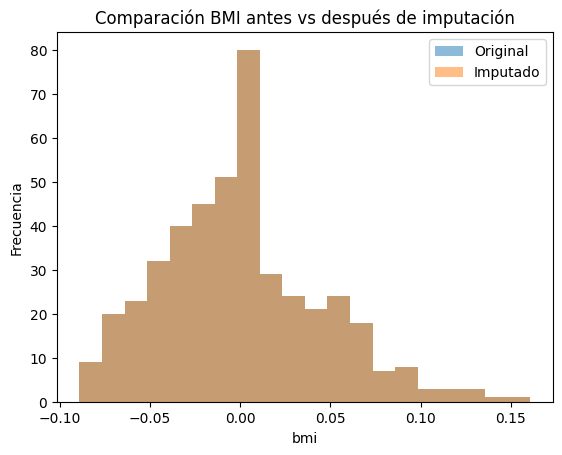

In [8]:
# Guardar versión original con NaN
data_original = data.copy()

# Imputación con media
imputer = SimpleImputer(strategy='mean')
data_imputado = data.copy()
data_imputado['bmi'] = imputer.fit_transform(data_imputado[['bmi']])

# Histograma comparativo
plt.figure()

plt.hist(data_original['bmi'].dropna(), bins=20, alpha=0.5, label='Original')
plt.hist(data_imputado['bmi'], bins=20, alpha=0.5, label='Imputado')

plt.legend()
plt.title('Comparación BMI antes vs después de imputación')
plt.xlabel('bmi')
plt.ylabel('Frecuencia')

plt.show()